In [1]:
"""
NOTE: You can copy this file and make another ipynb for other model and dataset
TODO: You can improve this code to read all the dir and train all of the model in this 1 file but for now it is only Cu

===============================================================================
Cu (Copper) Concentration Prediction - Random Forest Training Script
===============================================================================

This script is structured in blocks (cells) so you can copy each block
into a Jupyter Notebook (.ipynb) cell.

Pipeline:
  1. Load images from dataset folder
  2. Crop center region & extract mean RGB values
  3. Parse concentration from filename
  4. Save to CSV dataset
  5. Train Random Forest Regressor with hyperparameter tuning
  6. Evaluate model performance
  7. Save trained model (.pkl)
"""

'\nNOTE: You can copy this file and make another ipynb for other model and dataset\nTODO: You can improve this code to read all the dir and train all of the model in this 1 file but for now it is only Cu\n\n===============================================================================\nCu (Copper) Concentration Prediction - Random Forest Training Script\n===============================================================================\n\nThis script is structured in blocks (cells) so you can copy each block\ninto a Jupyter Notebook (.ipynb) cell.\n\nPipeline:\n  1. Load images from dataset folder\n  2. Crop center region & extract mean RGB values\n  3. Parse concentration from filename\n  4. Save to CSV dataset\n  5. Train Random Forest Regressor with hyperparameter tuning\n  6. Evaluate model performance\n  7. Save trained model (.pkl)\n'

In [18]:
import os
import re
import sys
import csv
import time
import joblib
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

from utils.helper import parse_concentration_from_filename, extract_center_crop_rgb, build_dataset

In [3]:
# Configuration 
IMAGE_FOLDER = os.path.join(os.getcwd(), "dataset", "cu_pict")
OUTPUT_CSV_DIR = os.path.join(os.getcwd(), "csv_dataset")
OUTPUT_CSV = os.path.join(OUTPUT_CSV_DIR, "csv_cu_dataset.csv")
OUTPUT_MODEL_DIR = os.path.join(os.getcwd(), "model")
OUTPUT_MODEL = os.path.join(OUTPUT_MODEL_DIR, "cu_model.pkl")
CROP_BOX_WIDTH = 100  # Width of center crop region (pixels)
CROP_BOX_HEIGHT = 100  # Height of center crop region (pixels)
CROP_OFFSET_X = 65  # Horizontal offset from center (pixels)
CROP_OFFSET_Y = 750 # Vertical offset from center (pixels)
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# Create output directories if they don't exist
os.makedirs(OUTPUT_CSV_DIR, exist_ok=True)
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)

In [4]:
print(f"Image folder : {IMAGE_FOLDER}")
print(f"Output CSV   : {OUTPUT_CSV}")
print(f"Output model : {OUTPUT_MODEL}")
print(f"Crop box     : {CROP_BOX_WIDTH}x{CROP_BOX_HEIGHT} px")

Image folder : c:\College_Computer_Science\PIPP\tutor-ai-farmasi\ai_train\dataset\cu_pict
Output CSV   : c:\College_Computer_Science\PIPP\tutor-ai-farmasi\ai_train\csv_dataset\csv_cu_dataset.csv
Output model : c:\College_Computer_Science\PIPP\tutor-ai-farmasi\ai_train\model\cu_model.pkl
Crop box     : 100x100 px


Mean RGB: R=222.68, G=178.55, B=208.91
Width of the image: 4624
Height of the image: 3468


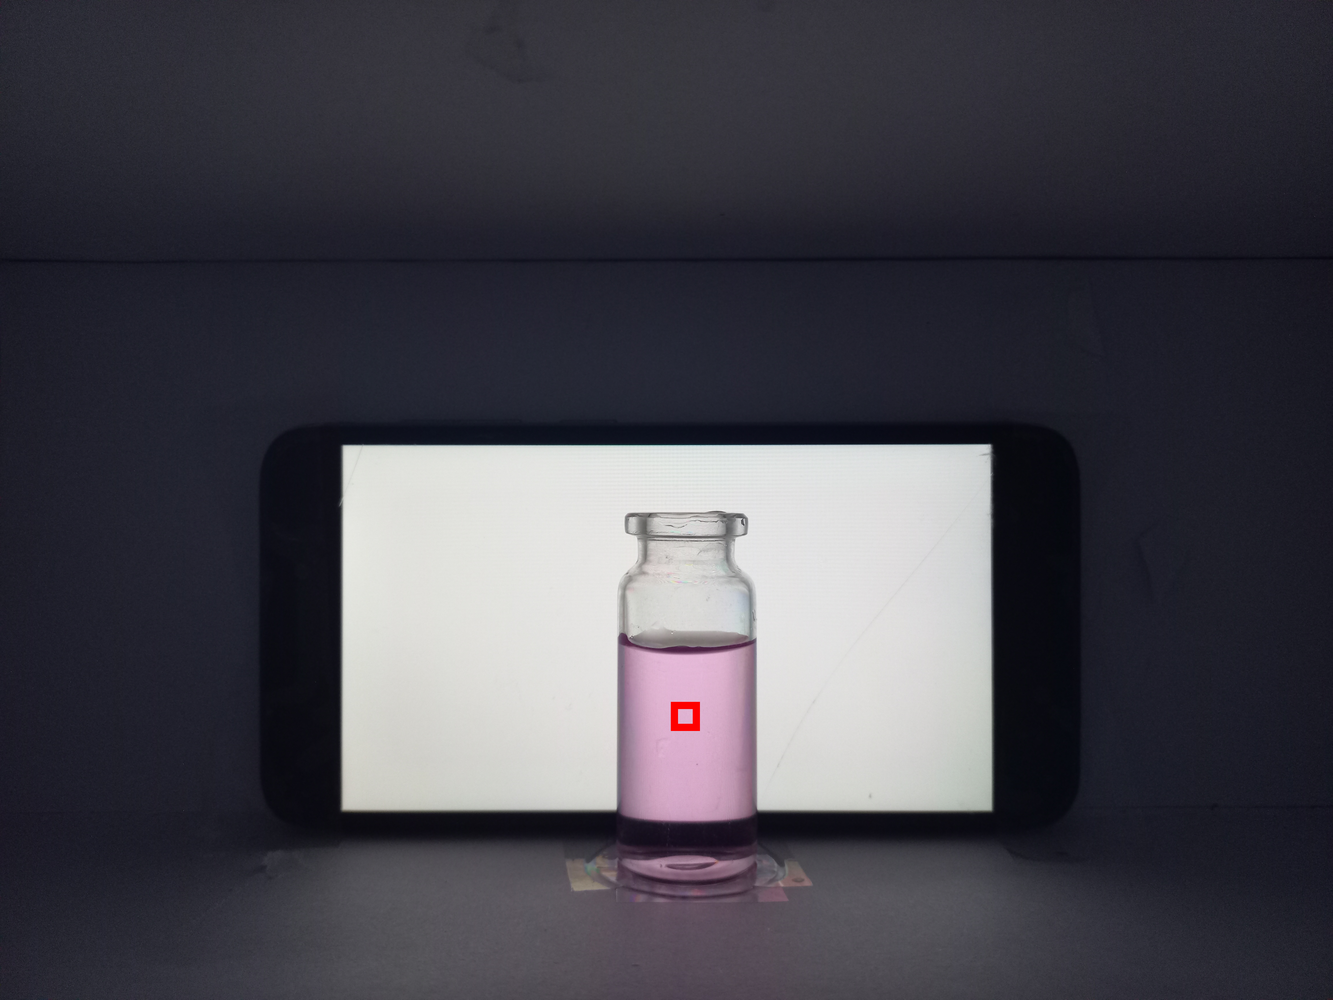

In [5]:
from PIL import ImageDraw
from IPython.display import display

# Test extraction and visualize crop box (RED with offsets)
test_image_filename = "0,1a (1).jpg"
test_image_path = os.path.join(IMAGE_FOLDER, test_image_filename)

if os.path.exists(test_image_path):
    # 1. Run the extraction (now uses global offsets)
    r, g, b = extract_center_crop_rgb(test_image_path, CROP_BOX_WIDTH, CROP_BOX_HEIGHT, CROP_OFFSET_X, CROP_OFFSET_Y)
    print(f"Mean RGB: R={r:.2f}, G={g:.2f}, B={b:.2f}")

    # 2. Visualize
    img_viz = Image.open(test_image_path).convert("RGB")
    draw = ImageDraw.Draw(img_viz)
    w, h = img_viz.size
    print(f"Width of the image: {w}")
    print(f"Height of the image: {h}")
    
    # Uses global variables CROP_OFFSET_X, CROP_OFFSET_Y
    left = max((w - CROP_BOX_WIDTH) // 2 + CROP_OFFSET_X, 0)
    top = max((h - CROP_BOX_HEIGHT) // 2 + CROP_OFFSET_Y, 0)
    right = min(left + CROP_BOX_WIDTH, w)
    bottom = min(top + CROP_BOX_HEIGHT, h)

    # Draw a RED box (as requested) and crosshair
    draw.rectangle([left, top, right, bottom], outline="red", width=25)

    # Display (auto-resized for viewing)
    if h > 1000:
        scale = 1000 / h
        img_viz = img_viz.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    
    display(img_viz)
else:
    print(f"Image not found: {test_image_path}")


In [9]:
# Run the dataset builder
df = build_dataset(IMAGE_FOLDER, OUTPUT_CSV, CROP_BOX_WIDTH, CROP_BOX_HEIGHT, CROP_OFFSET_X, CROP_OFFSET_Y)

['0,1a (1).jpg', '0,1a (2).jpg', '0,1a (3).jpg', '0,1a (4).jpg', '0,1a (5).jpg']

Found 450 image files in 'c:\College_Computer_Science\PIPP\tutor-ai-farmasi\ai_train\dataset\cu_pict'
  Processed 50/450 images...
  Processed 100/450 images...
  Processed 150/450 images...
  Processed 200/450 images...
  Processed 250/450 images...
  Processed 300/450 images...
  Processed 350/450 images...
  Processed 400/450 images...
  Processed 450/450 images...

Successfully processed 450 images.
Dataset saved to: c:\College_Computer_Science\PIPP\tutor-ai-farmasi\ai_train\csv_dataset\csv_cu_dataset.csv
   Shape: (450, 5)

Concentration distribution:
concentration
0.0    45
0.1    45
0.2    45
0.5    45
0.8    45
1.0    45
1.2    45
1.5    45
2.0    45
2.5    45
Name: count, dtype: int64


In [10]:
print(f"\nDataset overview:")
print(f"   Total samples : {len(df)}")
print(f"   Features      : mean_R, mean_G, mean_B")
print(f"   Target         : concentration")
print(f"\n{df.describe()}")

# Feature Engineering
feature_cols = ["mean_R", "mean_G", "mean_B"]

# Add derived features
total_rgb = df["mean_R"] + df["mean_G"] + df["mean_B"]
df["r_norm"] = df["mean_R"] / total_rgb
df["g_norm"] = df["mean_G"] / total_rgb
df["b_norm"] = df["mean_B"] / total_rgb

# # RGB ratios
# df["r_g_ratio"] = df["mean_R"] / (df["mean_G"] + 1)
# df["r_b_ratio"] = df["mean_R"] / (df["mean_B"] + 1)
# df["g_b_ratio"] = df["mean_G"] / (df["mean_B"] + 1)

feature_cols = [
    "mean_R", "mean_G", "mean_B",
    "r_norm", "g_norm", "b_norm",
    # "r_g_ratio", "r_b_ratio", "g_b_ratio",
]

X = df[feature_cols].values
y = df["concentration"].values

print(f"\nFeature matrix X shape : {X.shape}")
print(f"Target vector y shape  : {y.shape}")
print(f"Features used          : {feature_cols}")


Dataset overview:
   Total samples : 450
   Features      : mean_R, mean_G, mean_B
   Target         : concentration

           mean_R      mean_G      mean_B  concentration
count  450.000000  450.000000  450.000000     450.000000
mean   222.789871  184.602120  205.164204       0.980000
std      2.108670    5.870925    3.729320       0.793094
min    217.352000  172.717000  196.843000       0.000000
25%    221.358000  179.311750  202.373000       0.200000
50%    222.849500  183.710000  205.494500       0.900000
75%    224.160250  189.848250  207.470500       1.500000
max    230.261000  196.940000  218.143000       2.500000

Feature matrix X shape : (450, 6)
Target vector y shape  : (450,)
Features used          : ['mean_R', 'mean_G', 'mean_B', 'r_norm', 'g_norm', 'b_norm']


In [ ]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"\nTrain/Test Split:")
print(f"   Train set : {X_train.shape[0]} samples")
print(f"   Test set  : {X_test.shape[0]} samples")
print(f"   Test size : {TEST_SIZE*100:.0f}%")

# Random Forest single model training
N_ESTIMATORS = 350
MAX_DEPTH = None
MIN_SAMPLES_SPLIT = 2
MIN_SAMPLES_LEAF = 1
MAX_FEATURES = None
BOOTSTRAP = True
N_JOBS = -1
RF_RANDOM_STATE = 42

pipeline_single = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_features=MAX_FEATURES,
        bootstrap=BOOTSTRAP,
        n_jobs=N_JOBS,
        random_state=RF_RANDOM_STATE,
        verbose=0,
    ))
])

print("\nTraining Random Forest model...")
start_time = time.time()

pipeline_single.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} seconds.")

# Evaluate single model
y_pred_train = pipeline_single.predict(X_train)
y_pred_test = pipeline_single.predict(X_test)

print(f"\nSingle Model Performance:")
print(f"   Training Set:")
print(f"   MAE  : {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"   RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"   R2   : {r2_score(y_train, y_pred_train):.4f}")
print(f"   Test Set:")
print(f"   MAE  : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"   RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"   R2   : {r2_score(y_test, y_pred_test):.4f}")


Train/Test Split:
   Train set : 360 samples
   Test set  : 90 samples
   Test size : 20%

Training Random Forest model...
Training completed in 0.28 seconds.

Single Model Performance:
   Training Set:
   MAE  : 0.0105
   RMSE : 0.0232
   R2   : 0.9991
   Test Set:
   MAE  : 0.0440
   RMSE : 0.0860
   R2   : 0.9897
   MAPE : 866406785456054.75%


In [ ]:
# GridSearchCV for hyperparameter tuning
param_grid = {
    "rf__n_estimators": [100, 200, 350, 500],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": [None, "sqrt", "log2"],
}

CV_FOLDS = 5
SCORING = "r2"
GRID_VERBOSE = 1

pipeline_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_jobs=N_JOBS,
        random_state=RF_RANDOM_STATE,
    ))
])

print(f"\nStarting GridSearchCV with {CV_FOLDS}-fold cross-validation...")
print(f"   Scoring metric : {SCORING}")

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f"   Total combinations: {total_combos}")
print(f"   Total fits: {total_combos * CV_FOLDS}")

start_time = time.time()

grid_search = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    cv=CV_FOLDS,
    scoring=SCORING,
    verbose=GRID_VERBOSE,
    n_jobs=N_JOBS,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"\nGridSearchCV completed in {elapsed:.2f} seconds.")

# Best parameters and score
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nBest CV Score ({SCORING}): {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"\nBest Model - Test Set Performance:")
print(f"   MAE  : {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"   RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"   R2   : {r2_score(y_test, y_pred_best):.4f}")


Starting GridSearchCV with 5-fold cross-validation...
   Scoring metric : r2
   Total combinations: 432
   Total fits: 2160
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

GridSearchCV completed in 107.63 seconds.

Best Parameters:
   rf__max_depth: None
   rf__max_features: sqrt
   rf__min_samples_leaf: 1
   rf__min_samples_split: 2
   rf__n_estimators: 100

Best CV Score (r2): 0.9942

Best Model - Test Set Performance:
   MAE  : 0.0441
   RMSE : 0.0738
   R2   : 0.9924
   MAPE : 1090871909740868.75%


In [20]:
# Cross-validation for robust performance estimate
# since our x and y data is sorted which is bad, we need to shuffle it first
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model, X, y,
    cv=kf,
    scoring="r2",
)

print(f"\nCross-Validation R2 Scores ({CV_FOLDS}-fold):")
for i, score in enumerate(cv_scores):
    print(f"   Fold {i+1}: {score:.4f}")
print(f"   Mean  : {cv_scores.mean():.4f}")
print(f"   Std   : {cv_scores.std():.4f}")

cv_mae = cross_val_score(
    best_model, X, y,
    cv=kf,
    scoring="neg_mean_absolute_error",
)
print(f"\nCross-Validation MAE ({CV_FOLDS}-fold):")
for i, score in enumerate(cv_mae):
    print(f"   Fold {i+1}: {-score:.4f}")
print(f"   Mean MAE : {-cv_mae.mean():.4f}")


Cross-Validation R2 Scores (5-fold):
   Fold 1: 0.9926
   Fold 2: 0.9945
   Fold 3: 0.9944
   Fold 4: 0.9975
   Fold 5: 0.9944
   Mean  : 0.9947
   Std   : 0.0016

Cross-Validation MAE (5-fold):
   Fold 1: 0.0461
   Fold 2: 0.0370
   Fold 3: 0.0347
   Fold 4: 0.0246
   Fold 5: 0.0334
   Mean MAE : 0.0352


In [21]:
# Feature importance from best model
rf_model = best_model.named_steps["rf"]
importances = rf_model.feature_importances_

print(f"\nFeature Importance:")
print(f"{'Feature':<20} {'Importance':>10}")
print("-" * 32)

sorted_idx = np.argsort(importances)[::-1]
for idx in sorted_idx:
    print(f"{feature_cols[idx]:<20} {importances[idx]:>10.4f}")


Feature Importance:
Feature              Importance
--------------------------------
g_norm                   0.3389
b_norm                   0.2864
mean_G                   0.2355
r_norm                   0.0887
mean_B                   0.0461
mean_R                   0.0045


In [22]:
# Save model with metadata
model_to_save = best_model

model_artifact = {
    "pipeline": model_to_save,
    "feature_columns": feature_cols,
    "target_column": "concentration",
    "metrics": {
        "mae": mean_absolute_error(y_test, y_pred_best),
        "rmse": float(np.sqrt(mean_squared_error(y_test, y_pred_best))),
        "r2": r2_score(y_test, y_pred_best),
        "cv_r2_mean": float(cv_scores.mean()),
        "cv_r2_std": float(cv_scores.std()),
    },
    "config": {
        "crop_box": f"{CROP_BOX_WIDTH}x{CROP_BOX_HEIGHT}",
        "test_size": TEST_SIZE,
        "best_params": grid_search.best_params_,
    },
}

os.makedirs(os.path.dirname(OUTPUT_MODEL) or ".", exist_ok=True)
joblib.dump(model_artifact, OUTPUT_MODEL)

print(f"\nModel saved to: {OUTPUT_MODEL}")
print(f"   Features : {feature_cols}")
print(f"   Metrics  : MAE={model_artifact['metrics']['mae']:.4f}, R2={model_artifact['metrics']['r2']:.4f}")
print(f"   CV R2    : {model_artifact['metrics']['cv_r2_mean']:.4f} +/- {model_artifact['metrics']['cv_r2_std']:.4f}")


Model saved to: c:\College_Computer_Science\PIPP\tutor-ai-farmasi\ai_train\model\cu_model.pkl
   Features : ['mean_R', 'mean_G', 'mean_B', 'r_norm', 'g_norm', 'b_norm']
   Metrics  : MAE=0.0441, R2=0.9924
   CV R2    : 0.9947 +/- 0.0016


In [23]:
# Load and test the saved model
loaded = joblib.load(OUTPUT_MODEL)
loaded_pipeline = loaded["pipeline"]
loaded_features = loaded["feature_columns"]

print(f"\nPrediction Test (first 5 test samples):")
print(f"{'Actual':>10} {'Predicted':>10} {'Error':>10}")
print("-" * 32)

for i in range(min(5, len(y_test))):
    actual = y_test[i]
    predicted = y_pred_best[i]
    error = abs(actual - predicted)
    print(f"{actual:>10.3f} {predicted:>10.3f} {error:>10.3f}")

print(f"\nTraining complete. Model ready at: {OUTPUT_MODEL}")


Prediction Test (first 5 test samples):
    Actual  Predicted      Error
--------------------------------
     2.000      1.980      0.020
     2.000      2.090      0.090
     0.500      0.502      0.002
     0.100      0.095      0.005
     2.000      1.980      0.020

Training complete. Model ready at: c:\College_Computer_Science\PIPP\tutor-ai-farmasi\ai_train\model\cu_model.pkl
